In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('titanic_data_set.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

***Deleting Unnecessary Features***

In [5]:
df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
df.head(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,no,third,male,22.0,1,0,7.2500,NaN,S
1,yes,first,female,38.0,1,0,71.2833,C85,C
2,yes,third,female,26.0,0,0,7.9250,NaN,S
3,yes,first,female,35.0,1,0,53.1000,C123,S
4,no,third,male,35.0,0,0,8.0500,NaN,S


***separating features and target columns***

In [6]:
# features 
x = df.drop(['Survived'], axis=1)

In [7]:
# target 
y = df['Survived']

***Train Test Split***

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

***Imputing Missing Values***

***Neumerical Values***

In [9]:
x_train.isnull().sum()

Pclass        0
Sex           0
Age         140
SibSp         0
Parch         0
Fare          0
Cabin       553
Embarked      2
dtype: int64

***By Pandas***

***Mean Impute***

In [10]:
age_mean = x_train['Age'].mean()

x_train['Age Mean Imputor'] = x_train['Age'].fillna(age_mean)

In [11]:
age_mean = x_test['Age'].mean()

x_test['Age Mean Imputor'] = x_test['Age'].fillna(age_mean)

***Median Impute***

In [12]:
age_median = x_train['Age'].median()

x_train['Age Median Imputor'] = x_train['Age'].fillna(age_mean)

In [13]:
age_meadian = x_test['Age'].median()

x_test['Age Median Imputor'] = x_test['Age'].fillna(age_mean)

<Axes: xlabel='Age Mean Imputor', ylabel='Density'>

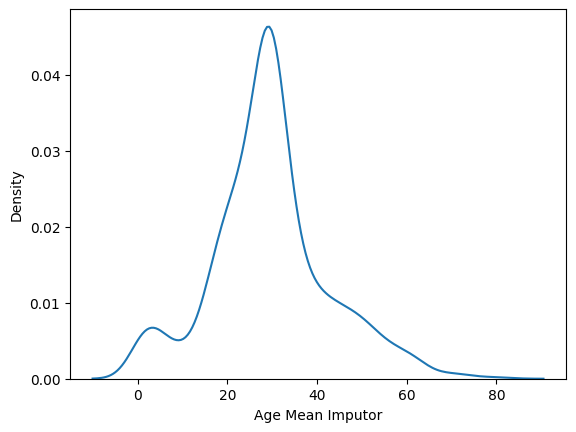

In [14]:
sns.kdeplot(data=x_train, x='Age Mean Imputor')

<Axes: xlabel='Age Median Imputor', ylabel='Density'>

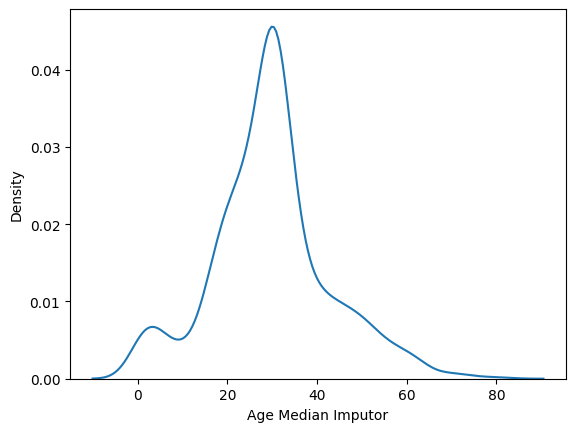

In [15]:
sns.kdeplot(data=x_train, x='Age Median Imputor')

In [16]:
x_train.drop(['Age Mean Imputor', 'Age Median Imputor'], axis=1, inplace=True)
x_test.drop(['Age Mean Imputor', 'Age Median Imputor'], axis=1, inplace=True)

***Simple Imputor of Numerical Values***

In [17]:
# Age (by mean)
age_imputor = SimpleImputer(missing_values=np.nan, strategy='mean')

age_imputor.fit(x_train[['Age']])

x_train['Age'] = age_imputor.transform(x_train[['Age']]).ravel()
x_test['Age'] = age_imputor.transform(x_test[['Age']]).ravel()

***Simple Imputor of Categrical Values***

In [18]:
# Embarked
embarked_imputor = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

embarked_imputor.fit(x_train[['Embarked']])

x_train['Embarked'] = embarked_imputor.transform(x_train[['Embarked']]).ravel()
x_test['Embarked'] = embarked_imputor.transform(x_test[['Embarked']]).ravel()

In [19]:
# Cabin
cabin_imputor = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='Missing', add_indicator=True)

cabin_imputor.fit(x_train[['Cabin']])

x_train[['Cabin', 'missing_indicator']] = cabin_imputor.transform(x_train[['Cabin']])
x_test[['Cabin', 'missing_indicator']] = cabin_imputor.transform(x_test[['Cabin']])